# TS 2025 - Assignment 2

Before you begin, set the assignment seed to the student id of one of your team members in the cell below.
To choose the data for this set the assignment seed to the student id of one of the team members. The
cell is prefilled with an **example** student id, so make sure to change it and **run the cell** before proceeding
further.

In [294]:
# NB!: change this to the student id of one of your team members

assignment_seed = "2675"

## Presentation

Do not create powerpoint slides or similar presentations for this assignment. The only submission should be
this Jupyter notebook with the completed code and results.

For the presentation of your results please **only include**:

    - Plots
    - Numeric results
    - Tables of model parameters and summaries

**Do not include**:

    - Text in comments or markdown cells
    - Custom functions in the code
    - if-then-else statements or similar control flow structures
    - Loops (for, while, etc.)
    - Any other code that is not directly related to the assignment tasks
  
**Explanations**

For the presentation you should be able to explain all the steps and be able to answer questions about

- Why you use a specific model/test/plot
- What is shown in the plots and numeric results
- How to interpret the results
  
## Tasks

1. Run the following cell to load your data. It will be stored in the pandas Series `dt`. All time series
are stock prices from the SOFIX index. The data that you should use for the model selection is stored in the
series `train`. The data for testing the forecasts is stored in the series `test`.

2. Adjust the labels and titles of the plots to reflect the stock you are analyzing
3. Your task is to select an ARIMA model for the stock price.
   - Choose the order of differencing based on the ACF/PACF plots and unit root tests (ADF, KPSS)
   - Choose the AR and MA orders based on the ACF/PACF plots and information criteria (AIC, BIC)
4. After selecting the ARIMA model, analyze the residuals
   - Plot the residuals and their ACF/PACF
   - Perform the Ljung-Box test on the residuals
   - Plot the histogram and QQ-plot of the residuals
5. Analyze the volatility of the residuals using an appropriate plot
6. Fit several ARCH/GARCH models to the residuals
   - Plot the conditional volatility
   - Analyze the standardized residuals of the GARCH model (plots, Ljung-Box test, histogram, QQ-plot)
   - Test whether negative and positive shocks have different effects on volatility
  
7. Forecast the stock prices for the test period using the ARIMA model in two ways:
   - By manually differencing the data before fitting the ARIMA model
   - By using the integrated ARIMA model directly
   - Compare the forecasts from both methods and explain the differences, explain the meaning of an
     intercept in the ARIMA model with differenced data
   - Plot the forecasts along with the actual values
   - Compute the RMSE of the forecasts

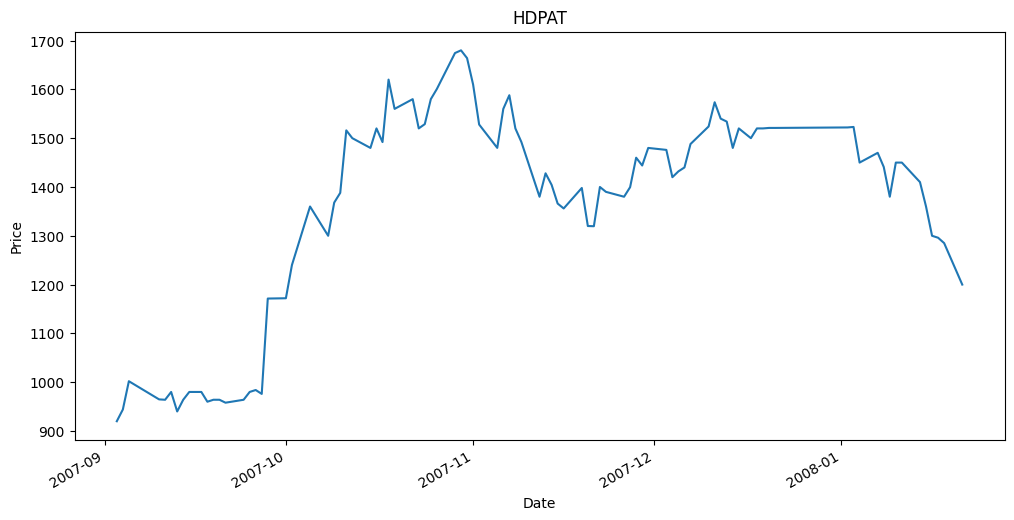

In [295]:

%pip install arch

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from arch import arch_model
from scipy import stats
import numpy as np

np.random.seed(int(re.sub(r"\D", "", assignment_seed)))

stocks = pd.read_excel("https://github.com/febse/data/raw/refs/heads/main/ts/SOFIX-Stocks.xlsx", usecols="A:Q").set_index("Date")

dt = stocks[np.random.choice(stocks.columns)]

train_size = int(len(dt) * 0.85)
train, test = dt[:train_size], dt[train_size:]


train.plot(title="Stock Price", figsize=(12, 6))

plt.xlabel("Date")
plt.ylabel("Price")
plt.title("HDPAT")
plt.show()

In [297]:
print(f"The stock being analyzed is: {dt.name}")

The stock being analyzed is: HDPAT


In [298]:
from statsmodels.tsa.stattools import adfuller

def show_adf_result(result):

    adf_stat = result[0]
    pvalue = result[1]
    critical_values = result[2]
    resstore = result[3]

    print("Augmented Dickey-Fuller Test Results")
    print("=" * 60)
    print(f"ADF Statistic: {adf_stat:.6f}")
    print(f"p-value: {pvalue:.6f}")
    print(f"Critical Values:")
    for k, v in critical_values.items():
        print(f"  {k}: {v:.2f}")
    print("=" * 60)
    print(resstore.resols.summary())


print("\n--- ADF Test on Original Training Data ---")

result_original_adf = adfuller(train.dropna(), regression='c', autolag='AIC', regresults=True, store=True)
show_adf_result(result_original_adf)


--- ADF Test on Original Training Data ---
Augmented Dickey-Fuller Test Results
ADF Statistic: -1.939065
p-value: 0.313912
Critical Values:
  1%: -3.50
  5%: -2.89
  10%: -2.58
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.040
Model:                            OLS   Adj. R-squared:                  0.029
Method:                 Least Squares   F-statistic:                     3.760
Date:                Tue, 13 Jan 2026   Prob (F-statistic):             0.0556
Time:                        09:27:08   Log-Likelihood:                -492.21
No. Observations:                  93   AIC:                             988.4
Df Residuals:                      91   BIC:                             993.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err

In [299]:
diff_train = train.diff().dropna()


print("\n--- ADF Test on First-Differenced Training Data ---")
result_diff = adfuller(diff_train, regression='c', autolag='AIC', regresults=True, store=True)
show_df_result_v2(result_diff)



--- ADF Test on First-Differenced Training Data ---
Augmented Dickey-Fuller Test Results
ADF Statistic: -9.970669
p-value: 0.000000
Critical Values
1%: -3.50
5%: -2.89
10%: -2.58
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.525
Model:                            OLS   Adj. R-squared:                  0.520
Method:                 Least Squares   F-statistic:                     99.41
Date:                Tue, 13 Jan 2026   Prob (F-statistic):           3.29e-16
Time:                        09:27:11   Log-Likelihood:                -488.98
No. Observations:                  92   AIC:                             982.0
Df Residuals:                      90   BIC:                             987.0
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std e

In [300]:
from statsmodels.tsa.stattools import kpss

def show_kpss_result(result, series_name):
    kpss_stat = result[0]
    pvalue = result[1]
    lags = result[2]
    critical_values = result[3]

    print(f"KPSS Test Results for {series_name}")
    print("=" * 60)
    print(f"KPSS Statistic: {kpss_stat:.6f}")
    print(f"p-value: {pvalue:.6f}")
    print(f"Number of Lags Used: {lags}")
    print(f"Critical Values:")
    for k, v in critical_values.items():
        print(f"  {k}: {v:.2f}")
    print("=" * 60)


print("\n--- KPSS Test on Original Training Data ---")
result_original_kpss = kpss(train.dropna(), regression='c', nlags='auto')
show_kpss_result(result_original_kpss, "Original Training Data")


print("\n--- KPSS Test on First-Differenced Training Data ---")


result_diff_kpss = kpss(diff_train, regression='c', nlags='auto')
show_kpss_result(result_diff_kpss, "First-Differenced Training Data")


--- KPSS Test on Original Training Data ---
KPSS Test Results for Original Training Data
KPSS Statistic: 0.780842
p-value: 0.010000
Number of Lags Used: 5
Critical Values:
  10%: 0.35
  5%: 0.46
  2.5%: 0.57
  1%: 0.74

--- KPSS Test on First-Differenced Training Data ---
KPSS Test Results for First-Differenced Training Data
KPSS Statistic: 0.553967
p-value: 0.029512
Number of Lags Used: 2
Critical Values:
  10%: 0.35
  5%: 0.46
  2.5%: 0.57
  1%: 0.74


/tmp/ipython-input-2933898007.py:21: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  result_original_kpss = kpss(train.dropna(), regression='c', nlags='auto')


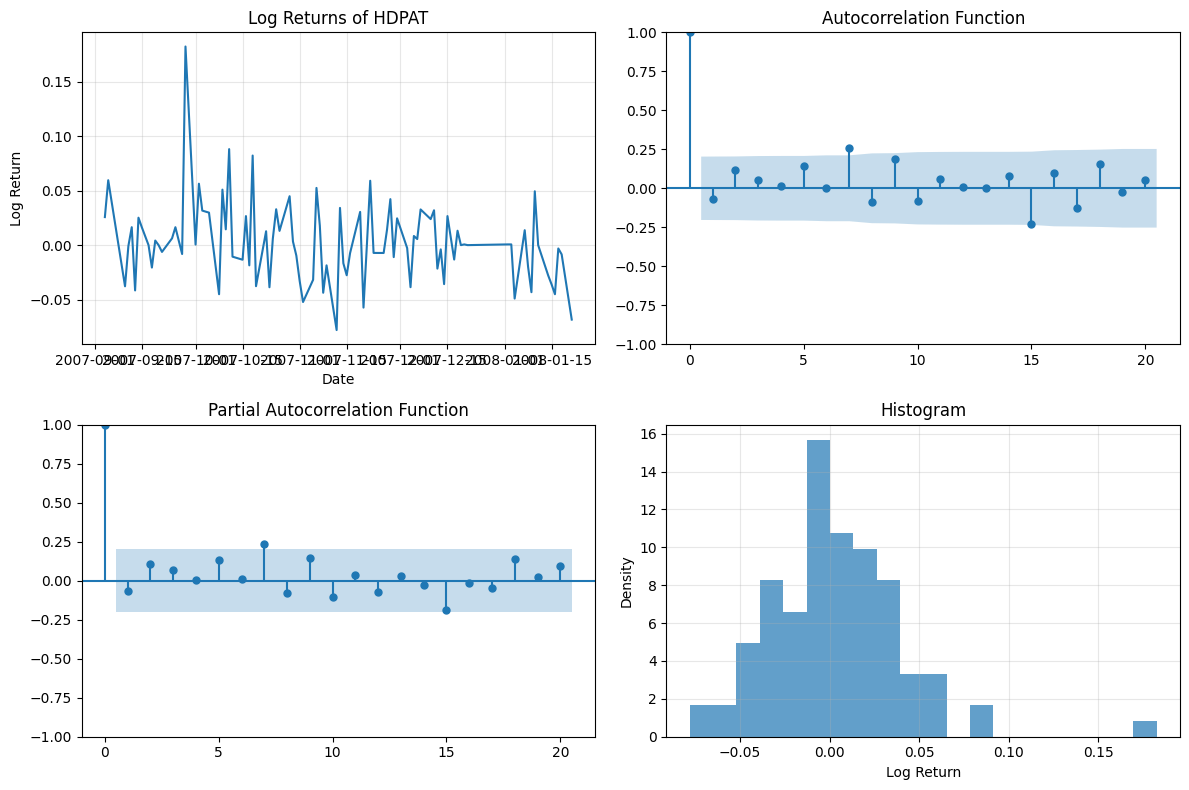

In [301]:
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf


log_returns = np.log(train).diff().dropna()


fig, ax = plt.subplots(2, 2, figsize=(12, 8))

ax[0, 0].plot(log_returns)
ax[0, 0].set_title(f"Log Returns of {dt.name}")
ax[0, 0].set_xlabel("Date")
ax[0, 0].set_ylabel("Log Return")
ax[0, 0].grid(alpha=0.3)

plot_acf(log_returns, lags=20, ax=ax[0, 1])
ax[0, 1].set_title(f"Autocorrelation Function")

plot_pacf(log_returns, lags=20, method="ywm", ax=ax[1, 0])
ax[1, 0].set_title(f"Partial Autocorrelation Function")

ax[1, 1].hist(log_returns, bins=20, density=True, alpha=0.7)
ax[1, 1].set_title(f"Histogram")
ax[1, 1].set_xlabel("Log Return")
ax[1, 1].set_ylabel("Density")
ax[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


In [302]:
orders = {
    "ARIMA(1,0,0)": (1, 0, 0),
    "ARIMA(0,0,1)": (0, 0, 1),
    "ARIMA(1,0,1)": (1, 0, 1),
    "ARIMA(1,1,1)": (1, 1, 1),
    "ARIMA(1,1,0)": (1, 1, 0),
    "ARIMA(0,1,1)": (0, 1, 1),
    "ARIMA(1,1,2)": (1, 1, 2),
    "ARIMA(1,1,3)": (1, 1, 3),
    "ARIMA(2,0,0)": (2, 0, 0),
    "ARIMA(2,1,0)": (2, 1, 0),
    "ARIMA(2,0,1)": (2, 0, 1),
    "ARIMA(2,1,1)": (2, 1, 1),
    "ARIMA(0,1,2)": (0, 1, 2),
    "ARIMA(3,1,2)": (3, 1, 2),
    "ARIMA(4,1,1)": (4, 1, 1),
    "ARIMA(5,1,1)": (5, 1, 1),
    "ARIMA(0,1,3)": (0, 1, 3)
}

results = {}

for name, order in orders.items():
    try:
        model = ARIMA(train.dropna(), order=order)
        fit_res = model.fit()
        results[name] = fit_res
        print("\n", "#" * 60)
        print(name)
        print(fit_res.summary())
    except Exception as e:
        print(f"\nFailed to fit {name}: {e}")

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)



 ############################################################
ARIMA(1,0,0)
                               SARIMAX Results                                
Dep. Variable:                  HDPAT   No. Observations:                   94
Model:                 ARIMA(1, 0, 0)   Log Likelihood                -500.634
Date:                Tue, 13 Jan 2026   AIC                           1007.268
Time:                        09:27:18   BIC                           1014.898
Sample:                             0   HQIC                          1010.350
                                 - 94                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       1206.9370    174.418      6.920      0.000     865.085    1548.789
ar.L1          0.9799      0.021     47.656      0.000 

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)



 ############################################################
ARIMA(1,1,2)
                               SARIMAX Results                                
Dep. Variable:                  HDPAT   No. Observations:                   94
Model:                 ARIMA(1, 1, 2)   Log Likelihood                -493.434
Date:                Tue, 13 Jan 2026   AIC                            994.868
Time:                        09:27:19   BIC                           1004.998
Sample:                             0   HQIC                           998.958
                                 - 94                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.1830      0.866     -0.211      0.833      -1.880       1.514
ma.L1          0.1321      0.866      0.152      0.879 

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


...

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)



 ############################################################
ARIMA(4,1,1)
                               SARIMAX Results                                
Dep. Variable:                  HDPAT   No. Observations:                   94
Model:                 ARIMA(4, 1, 1)   Log Likelihood                -491.484
Date:                Tue, 13 Jan 2026   AIC                            994.968
Time:                        09:27:20   BIC                           1010.163
Sample:                             0   HQIC                          1001.103
                                 - 94                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.8344      0.225     -3.714      0.000      -1.275      -0.394
ar.L2          0.0921      0.139      0.660      0.509 

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)



 ############################################################
ARIMA(5,1,1)
                               SARIMAX Results                                
Dep. Variable:                  HDPAT   No. Observations:                   94
Model:                 ARIMA(5, 1, 1)   Log Likelihood                -490.747
Date:                Tue, 13 Jan 2026   AIC                            995.494
Time:                        09:27:20   BIC                           1013.223
Sample:                             0   HQIC                          1002.652
                                 - 94                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.5734      0.319      1.797      0.072      -0.052       1.199
ar.L2          0.1555      0.169      0.919      0.358 

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


In [303]:
for name, res in results.items():
    print(f"{name}: AIC={res.aic:.3f}, BIC={res.bic:.3f}")


ARIMA(1,0,0): AIC=1007.268, BIC=1014.898
ARIMA(0,0,1): AIC=1181.670, BIC=1189.300
ARIMA(1,0,1): AIC=1009.061, BIC=1019.234
ARIMA(1,1,1): AIC=993.778, BIC=1001.376
ARIMA(1,1,0): AIC=992.191, BIC=997.256
ARIMA(0,1,1): AIC=992.255, BIC=997.320
ARIMA(1,1,2): AIC=994.868, BIC=1004.998
ARIMA(1,1,3): AIC=995.351, BIC=1008.014
ARIMA(2,0,0): AIC=1009.008, BIC=1019.181
ARIMA(2,1,0): AIC=992.950, BIC=1000.548
ARIMA(2,0,1): AIC=1010.606, BIC=1023.322
ARIMA(2,1,1): AIC=994.940, BIC=1005.070
ARIMA(0,1,2): AIC=992.946, BIC=1000.544
ARIMA(4,1,1): AIC=994.968, BIC=1010.163
ARIMA(5,1,1): AIC=995.494, BIC=1013.223
ARIMA(0,1,3): AIC=994.846, BIC=1004.976


In [304]:
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(dt, order=(0,1,1))
results = model.fit()
print(results.summary())


                               SARIMAX Results                                
Dep. Variable:                  HDPAT   No. Observations:                  111
Model:                 ARIMA(0, 1, 1)   Log Likelihood                -535.294
Date:                Tue, 13 Jan 2026   AIC                           1074.588
Time:                        09:27:25   BIC                           1079.989
Sample:                             0   HQIC                          1076.779
                                - 111                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.0277      0.123     -0.226      0.821      -0.268       0.213
sigma2      2349.4510    236.389      9.939      0.000    1886.137    2812.765
Ljung-Box (L1) (Q):                   0.00   Jarque-

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it is not monotonic and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it is not monotonic and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsm

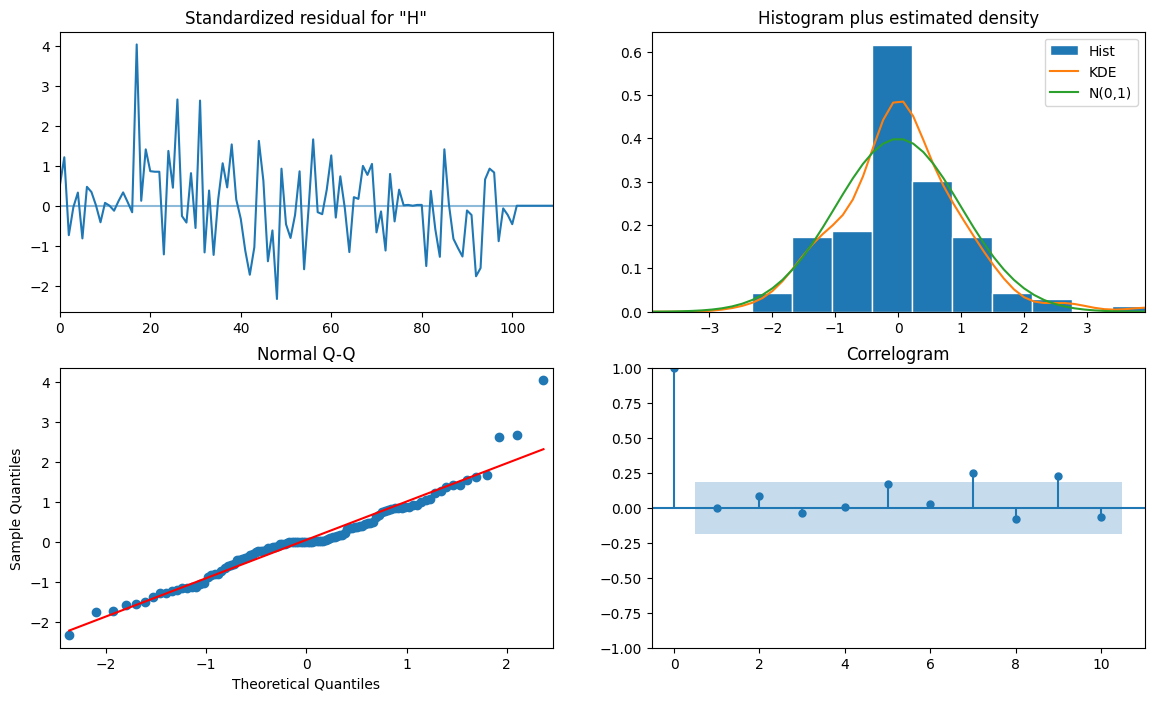

In [305]:
results.plot_diagnostics(figsize=(14, 8))
plt.show()

<Figure size 1000x400 with 0 Axes>

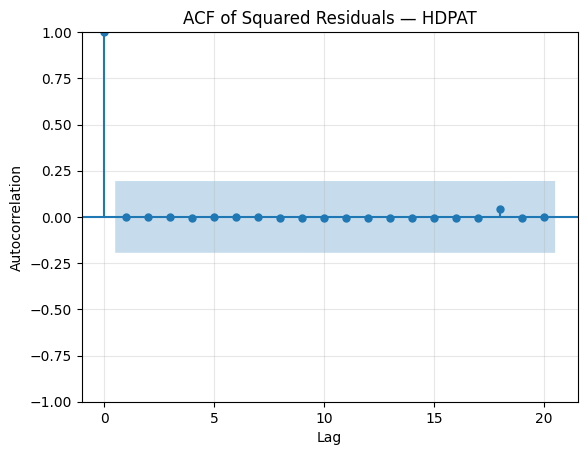

In [306]:
plt.figure(figsize=(10,4))
plot_acf(residuals_sq, lags=min(20, len(residuals_sq)-1))
plt.title("ACF of Squared Residuals — HDPAT")
plt.xlabel("Lag")
plt.ylabel("Autocorrelation")
plt.grid(alpha=0.3)
plt.show()


<Figure size 1000x400 with 0 Axes>

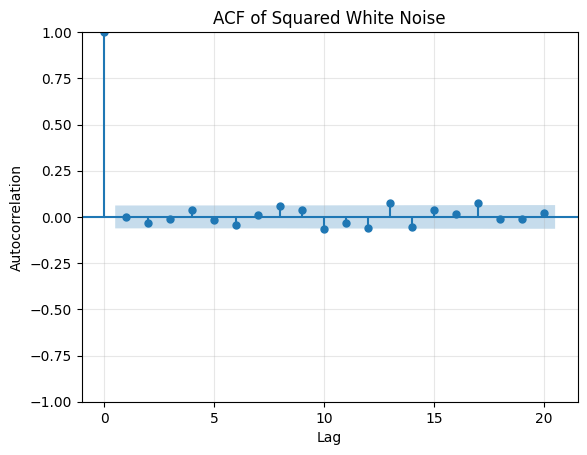

In [307]:
import numpy as np
from statsmodels.graphics.tsaplots import plot_acf
import matplotlib.pyplot as plt

np.random.seed(0)
white_noise = np.random.normal(size=1000)

plt.figure(figsize=(10, 4))
plot_acf(white_noise**2, lags=20)
plt.title("ACF of Squared White Noise")
plt.xlabel("Lag")
plt.ylabel("Autocorrelation")
plt.grid(alpha=0.3)
plt.show()


In [308]:
scaled_residuals = residuals.dropna() * 0.1

scaled_garch_model = arch_model(scaled_residuals, mean='Zero', vol='GARCH', p=1, q=1)
scaled_garch_results = scaled_garch_model.fit(disp='off')

print(scaled_garch_results.summary())

                       Zero Mean - GARCH Model Results                        
Dep. Variable:                   None   R-squared:                       0.000
Mean Model:                 Zero Mean   Adj. R-squared:                  0.010
Vol Model:                      GARCH   Log-Likelihood:               -322.343
Distribution:                  Normal   AIC:                           650.687
Method:            Maximum Likelihood   BIC:                           658.562
                                        No. Observations:                  102
Date:                Tue, Jan 13 2026   Df Residuals:                      102
Time:                        09:27:34   Df Model:                            0
                               Volatility Model                              
                 coef    std err          t      P>|t|       95.0% Conf. Int.
-----------------------------------------------------------------------------
omega          9.2376      3.291      2.807  5.004e-03 

<Figure size 1000x400 with 0 Axes>

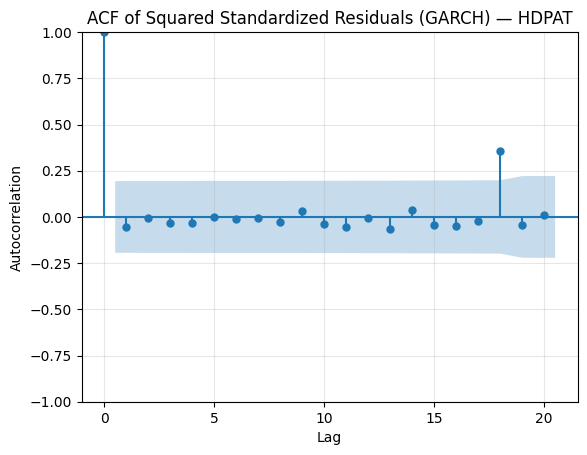

In [309]:
from statsmodels.graphics.tsaplots import plot_acf

std_resid = scaled_garch_results.std_resid
std_resid_sq = std_resid ** 2

plt.figure(figsize=(10, 4))
plot_acf(std_resid_sq, lags=20)
plt.title(f"ACF of Squared Standardized Residuals (GARCH) — {dt.name}")
plt.xlabel("Lag")
plt.ylabel("Autocorrelation")
plt.grid(alpha=0.3)
plt.show()

In [310]:
gjr_model = arch_model(
    scaled_residuals,
    mean="Zero",
    vol="GARCH",
    p=1,
    o=1,
    q=1
)
gjr_res = gjr_model.fit(disp="off")
print(gjr_res.summary())


                     Zero Mean - GJR-GARCH Model Results                      
Dep. Variable:                   None   R-squared:                       0.000
Mean Model:                 Zero Mean   Adj. R-squared:                  0.010
Vol Model:                  GJR-GARCH   Log-Likelihood:               -321.870
Distribution:                  Normal   AIC:                           651.740
Method:            Maximum Likelihood   BIC:                           662.240
                                        No. Observations:                  102
Date:                Tue, Jan 13 2026   Df Residuals:                      102
Time:                        09:27:38   Df Model:                            0
                               Volatility Model                              
                 coef    std err          t      P>|t|       95.0% Conf. Int.
-----------------------------------------------------------------------------
omega          9.9618      3.598      2.768  5.635e-03 

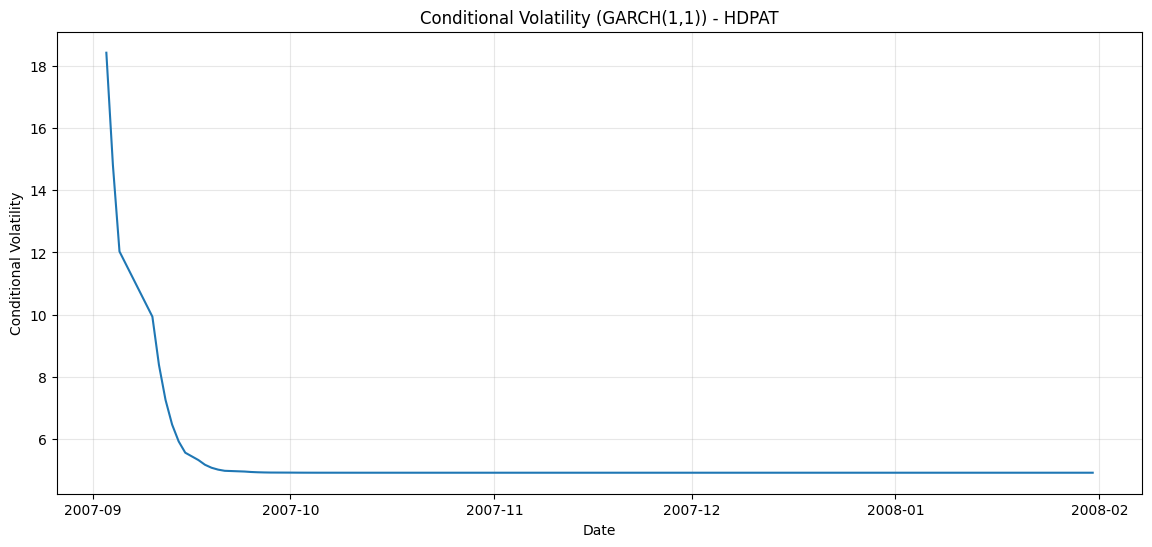

In [311]:
import matplotlib.pyplot as plt


plt.figure(figsize=(14, 6))
plt.plot(scaled_garch_results.conditional_volatility)
plt.title(f'Conditional Volatility (GARCH(1,1)) - {dt.name}')
plt.xlabel('Date')
plt.ylabel('Conditional Volatility')
plt.grid(alpha=0.3)
plt.show()

In [312]:
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error

dy_train = y_train.diff().dropna()

arma_model = ARIMA(dy_train, order=(1,1,0)).fit()

dy_forecast = arma_model.forecast(steps=h)

y_manual_forecast = y_train.iloc[-1] + dy_forecast.cumsum()
y_manual_forecast.index = y_test.index


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/p

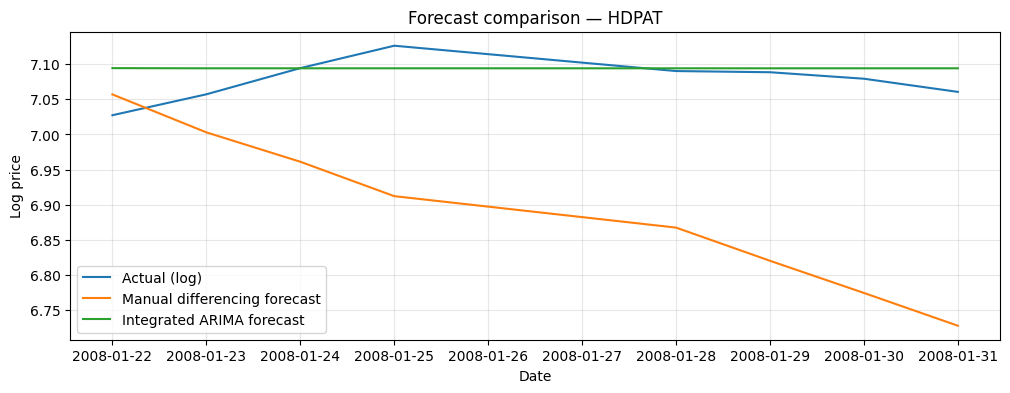

In [313]:
plt.figure(figsize=(12,4))
plt.plot(y_test.index, y_test, label="Actual (log)")
plt.plot(y_manual_forecast.index, y_manual_forecast, label="Manual differencing forecast")
plt.plot(y_integrated_forecast.index, y_integrated_forecast, label="Integrated ARIMA forecast")
plt.title("Forecast comparison — HDPAT")
plt.xlabel("Date")
plt.ylabel("Log price")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


In [314]:
rmse_manual = np.sqrt(mean_squared_error(y_test, y_manual_forecast))
rmse_integrated = np.sqrt(mean_squared_error(y_test, y_integrated_forecast))

print("RMSE (manual differencing):", rmse_manual)
print("RMSE (integrated ARIMA):", rmse_integrated)


RMSE (manual differencing): 0.2212830968984621
RMSE (integrated ARIMA): 0.032137469511439684
